In [35]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import TranscriptsDisabled
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field, ConfigDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage

from sklearn.metrics.pairwise import cosine_similarity

In [8]:
# featching YT video transcript

video_id = "EuBBz3bI-aA"   # only the ID, not full URL

try:
    api = YouTubeTranscriptApi()

    # list
    transcript_list = api.fetch(video_id).to_raw_data()
    print(transcript_list) 

    # Flatten it to plain text
    transcript = " ".join(chunk["text"] for chunk in transcript_list)
    print(transcript)


except TranscriptsDisabled:
    print("No captions available for this video.")

[{'text': 'Hurricane Florence came by while I was', 'start': 1.28, 'duration': 7.16}, {'text': 'working on StatQuest.', 'start': 4.88, 'duration': 7.0}, {'text': 'Dark clouds filled the sky, but that', 'start': 8.44, 'duration': 6.12}, {'text': "didn't stop StatQuest.", 'start': 11.88, 'duration': 5.68}, {'text': 'StatQuest.', 'start': 14.56, 'duration': 3.0}, {'text': "Hello, I'm Josh Starmer and welcome to", 'start': 18.16, 'duration': 4.08}, {'text': "StatQuest. Today, we're going to be", 'start': 20.36, 'duration': 3.48}, {'text': 'talking about some machine learning', 'start': 22.24, 'duration': 4.44}, {'text': 'fundamentals, bias and variance, and', 'start': 23.84, 'duration': 5.72}, {'text': "they're going to be clearly explained.", 'start': 26.68, 'duration': 4.64}, {'text': 'Imagine we measured the weight and', 'start': 29.56, 'duration': 4.08}, {'text': 'height of a bunch of mice and plotted', 'start': 31.32, 'duration': 4.84}, {'text': 'the data on a graph.', 'start': 33.64,

In [3]:
transcript_list

[{'text': 'Hurricane Florence came by while I was',
  'start': 1.28,
  'duration': 7.16},
 {'text': 'working on StatQuest.', 'start': 4.88, 'duration': 7.0},
 {'text': 'Dark clouds filled the sky, but that',
  'start': 8.44,
  'duration': 6.12},
 {'text': "didn't stop StatQuest.", 'start': 11.88, 'duration': 5.68},
 {'text': 'StatQuest.', 'start': 14.56, 'duration': 3.0},
 {'text': "Hello, I'm Josh Starmer and welcome to",
  'start': 18.16,
  'duration': 4.08},
 {'text': "StatQuest. Today, we're going to be",
  'start': 20.36,
  'duration': 3.48},
 {'text': 'talking about some machine learning',
  'start': 22.24,
  'duration': 4.44},
 {'text': 'fundamentals, bias and variance, and',
  'start': 23.84,
  'duration': 5.72},
 {'text': "they're going to be clearly explained.",
  'start': 26.68,
  'duration': 4.64},
 {'text': 'Imagine we measured the weight and',
  'start': 29.56,
  'duration': 4.08},
 {'text': 'height of a bunch of mice and plotted',
  'start': 31.32,
  'duration': 4.84},
 

In [4]:
transcript

"Hurricane Florence came by while I was working on StatQuest. Dark clouds filled the sky, but that didn't stop StatQuest. StatQuest. Hello, I'm Josh Starmer and welcome to StatQuest. Today, we're going to be talking about some machine learning fundamentals, bias and variance, and they're going to be clearly explained. Imagine we measured the weight and height of a bunch of mice and plotted the data on a graph. Light mice tend to be short, and heavier mice tend to be taller. But after a certain weight, mice don't get any taller, just more obese. Given this data, we would like to predict mouse height given its weight. For example, if you told me your mouse weighed this much, then we might predict that the mouse is this tall. Ideally, we would know the exact mathematical formula that describes the relationship between weight and height. But in this case, we don't know the formula, so we're going to use two machine learning methods to approximate this relationship. However, I'll leave the 

In [9]:
# chunking

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunk = splitter.create_documents([transcript])

In [10]:
len(chunk)

7

In [11]:
# Embedding Generation and Storing in Vector Store

embedding = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1639.25it/s]


In [12]:
vector_store = FAISS.from_documents(chunk, embedding)

In [13]:
# retriever

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [10]:
retriever.invoke('bias vs variance')

[Document(id='ffbed338-f9a8-46bd-bd1d-45bf68736c5a', metadata={}, page_content="set, it did a terrible job fitting the testing set. In machine learning lingo, the difference in fits between data sets is called variance. The squiggly line has low bias since it is flexible and can adapt to the curve in the relationship between weight and height. But the squiggly line has high variability because it results in vastly different sums of squares for different data sets. In other words, it's hard to predict how well the squiggly line will perform with future data sets. It might do well sometimes, and other times it might do terribly. In contrast, the straight line has relatively high bias since it cannot capture the curve in the relationship between weight and height. But the straight line has relatively low variance because the sums of squares are very similar for different data sets. In other words, the straight line might only give good predictions and not great predictions, but they will 

In [14]:
load_dotenv()

model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [12]:
prompt = PromptTemplate(
    template="""
      You are a helpful assistant.
      Answer ONLY from the provided transcript context.
      If the context is insufficient, just say you don't know.

      {context}
      Question: {question}
    """,
    input_variables = ['context', 'question']
)

In [13]:
question          = "is the topic of nuclear fusion discussed in this video? if yes then what was discussed"
retrieved_docs    = retriever.invoke(question)

In [14]:
retrieved_docs

[Document(id='a9a5508b-154b-412e-9d8b-7e0da983489a', metadata={}, page_content="an example of bagging in action. And we'll talk about regularization and boosting in future StatQuests. Double bam! Hooray! We've made it to the end of another exciting StatQuest. If you like this StatQuest and want to see more, please subscribe. And if you want to support StatQuest, well, please consider buying one or two of my original songs. All right, until next time, quest on."),
 Document(id='9bf21e10-b8a8-408a-9e8a-b3a44e9857a2', metadata={}, page_content="Hurricane Florence came by while I was working on StatQuest. Dark clouds filled the sky, but that didn't stop StatQuest. StatQuest. Hello, I'm Josh Starmer and welcome to StatQuest. Today, we're going to be talking about some machine learning fundamentals, bias and variance, and they're going to be clearly explained. Imagine we measured the weight and height of a bunch of mice and plotted the data on a graph. Light mice tend to be short, and heavie

In [15]:
context_text = "\n\n".join(doc.page_content for doc in retrieved_docs)

In [16]:
final_prompt = prompt.invoke({"context": context_text, "question": 'bias vs variance'})

In [17]:
answer = model.invoke(final_prompt)

print(answer.content)

**Bias vs. Variance (as described in the transcript)**  

| Aspect | What it means | Example from the transcript |
|--------|---------------|-----------------------------|
| **Bias** | The error introduced by approximating a real‑world problem with a simplified model. A high‑bias model is too simple to capture the underlying pattern. | The straight line (linear regression) has **high bias** because it cannot follow the curved relationship between weight and height. |
| **Variance** | The error introduced by a model’s sensitivity to the particular training data it was fitted on. A high‑variance model fits the training data very well but performs poorly on new data. | The squiggly line (a very flexible fit) has **low bias** (it can follow the curve) but **high variance** because it fits the training set perfectly yet fails badly on the testing set. |

**Key takeaway from the transcript:**  
- An ideal algorithm balances low bias (accurately captures the true relationship) with low varian

In [28]:
# schema

# summary agent
class Summary(BaseModel):
    model_config = ConfigDict(extra="forbid")
    summary : str = Field(...,description='summary of provided youtube video transcript.')

# key point agent
class Key_points(BaseModel):
    model_config = ConfigDict(extra="forbid")
    KeyPoints : List[str] = Field(...,description='key points from provided youtube video transcript.')

# fact check agent
class FactCheckItem(BaseModel):
    model_config = ConfigDict(extra="forbid")
    claim: str = Field(
        description="A factual claim made in the YouTube transcript."
    )
    verdict: str = Field(
        description="One of: TRUE, FALSE, MISLEADING, or UNVERIFIED."
    )
    explanation: str = Field(
        description="Brief explanation of why the claim received this verdict."
    )
    evidence: str = Field(
        description="Evidence from reliable external sources."
    )
    sources: List[str] = Field(
        description="URLs of sources used to verify the claim."
    )

class FactCheckResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    claims: List[FactCheckItem]

# topic extractor agent
class Topics(BaseModel):
    model_config = ConfigDict(extra="forbid")
    topics : List[str] = Field(
        description=(
            "Important concepts, subjects, technologies, methods, "
            "or entities discussed in the transcript."
        )
    )

# reference agent
class ReferenceItem(BaseModel):
    model_config = ConfigDict(extra="forbid")
    topic: str = Field(
        description="The topic this reference belongs to."
    )
    title: str = Field(
        description="Exact title of the selected source."
    )
    url: str = Field(
        description="Exact URL copied from the search result."
    )
    source_type: str = Field(
        description=(
            "Type of source: official documentation, research paper, "
            "university, government, textbook, or reputable article."
        )
    )
    relevance: str = Field(
        description="Briefly explain why this source is useful for this topic."
    )


class ReferenceResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    references: List[ReferenceItem]


# Que.-Ans. agent
class QueAns(BaseModel):
    model_config = ConfigDict(extra="forbid")
    answer: str = Field(
        description="Answer to the user's question based only on the provided context."
    )

In [5]:
class State(TypedDict):
    video_transcript : str
    summary : str
    KeyPoints : list[str]
    claims: Annotated[list[str], operator.add]
    fact_check : list
    topics : list[str]
    references : list
    question : str
    context : str
    answer  : str

In [29]:
# que-ans agent

def QueAns_agent(state: State) -> dict:

    context = '\n\n'.join(doc.page_content for doc in retriever.invoke(state['question']))

    response = model.with_structured_output(QueAns, method='json_schema', strict=False).invoke(
        [
            SystemMessage(
                content=f"""
- you are helpfull que-ans assistant.
- Answer ONLY from the provided transcript context.
- Don't answer outside from the context.
- Give answer in 5-6 Line. 

context:
{context}

Question:
{state['question']}
"""
            ),

            HumanMessage(content=state['question'])
        ]
    )

    return {'answer':response.answer}

In [15]:
# summary agent

def summary_agent(state: State) -> dict:

    response = model.with_structured_output(Summary, method='json_schema', strict=False).invoke(
        [
            SystemMessage(
                content=f"""
                You are a helpful summary assistant.

                Create a detailed but concise summary of the YouTube video transcript.

                Use ONLY information present in the transcript.
                Do not add outside information.

                Transcript:
                {state["video_transcript"]}
                """
            )
        ]
    )


    return {'summary':response.summary}

In [16]:
# key point extractor agent

def KeyPoint_agent(state: State) -> dict:

    response = model.with_structured_output(Key_points, method='json_schema', strict=False).invoke(
        [
            SystemMessage(
                content=f"""
                You are a key points extractor agent from provided youtube video transcripts.

                refere only provided transcrip. if you dont find any key points just say: 'can't find any usefull key points from the video.'

                Transcript:
                {state["video_transcript"]}
                """
            )
        ]
    )

    return {'KeyPoints':response.KeyPoints}

In [ ]:
def split_transcript_for_claims(state: State):

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=4000,
        chunk_overlap=500
    )

    chunks = splitter.split_text(
        state["video_transcript"]
    )

    return [
        Send(
            "claim_chunk_agent",
            {
                "video_transcript": chunk
            }
        )
        for chunk in chunks
    ]

In [ ]:
class Claims(BaseModel):
    model_config = ConfigDict(extra="forbid")
    claims: list[str]


def claim_chunk_agent(state: State) -> dict:

    response = model.with_structured_output(
        Claims,
        method="json_schema",
        strict=False
    ).invoke(
        f"""
Extract objectively verifiable factual claims from this transcript
chunk.

Rules:
- Extract only claims explicitly stated in the text.
- Do not add outside knowledge.
- Do not extract opinions.
- Do not extract questions.
- Do not extract advertisements.
- Do not extract calls to action.
- Do not repeat the same claim.
- Keep each claim short and factual.
- If there are no factual claims, return an empty list.

Transcript chunk:

{state["video_transcript"]}
"""
    )

    return {
        "claims": response.claims
    }

In [19]:
def deduplicate_claims(state: State) -> dict:
    claims = state['claims']

    if len(claims) <= 1:
        return {'cliams':claims}

    # embedding
    vectors = embedding.embed_documents(claims)

    unique_claims=[]
    unique_vectors=[]

    threshold = 0.85

    for cliam, vector in zip(claims, vectors):

        if not unique_vectors:
            unique_claims.append(cliam)
            unique_vectors.append(vector)
            continue

        similarities = cosine_similarity([vector], unique_vectors)[0]

        max_similarity = max(similarities)

        if max_similarity < threshold:
            unique_claims.append(cliam)
            unique_vectors.append(vector)


    return {'claims':unique_claims}

In [20]:
from langchain_tavily import TavilySearch

search = TavilySearch(
    max_results=3
)

In [21]:
# fact_check agent

def fact_checker(state: State) -> dict:

    results = []

    for claim in state["claims"]:

        search_result = search.invoke({
            "query": claim
        })

        response = model.with_structured_output(
            FactCheckResult, method="json_schema", strict=False
        ).invoke(
            [
                SystemMessage(
                    content="""
You are an expert fact checker.

Verify the provided claim using the external
search results.

Possible verdicts:

TRUE
FALSE
MISLEADING
UNVERIFIED

Rules:

- TRUE:
  Reliable evidence supports the claim.

- FALSE:
  Reliable evidence contradicts the claim.

- MISLEADING:
  The claim contains some truth but gives
  a misleading impression or lacks important context.

- UNVERIFIED:
  There isn't enough reliable evidence to determine
  whether the claim is true or false.

Do NOT rely on your internal knowledge when
the provided evidence is insufficient.

Prefer reliable sources such as:
- government websites
- official statistics
- scientific papers
- universities
- established news organizations
- primary sources

Claim:
"""
                    + claim
                    + """

Search results:
"""
                    + str(search_result)
                )
            ]
        )

        results.append(response.model_dump())

    return {
        "fact_check": results
    }

In [22]:
def topic_agent(state: State) -> dict:

    response = model.with_structured_output(Topics, method="json_schema", strict=False).invoke(
        [
            SystemMessage(
                content="""
You are a STRICT TOPIC EXTRACTION AGENT.

Your ONLY task is to identify the important topics and concepts
discussed in the provided YouTube transcript.

Extract topics that are useful for:
- finding authoritative references
- further learning
- researching the subject
- understanding the technical or factual content

RULES:

1. Extract ONLY topics explicitly discussed in the transcript.
2. Do NOT infer topics that are not present.
3. Do NOT summarize the transcript.
4. Do NOT extract complete sentences.
5. Do NOT extract opinions or personal statements.
6. Do NOT extract promotional content.
7. Do NOT extract calls to action such as:
   - subscribe
   - like
   - comment
   - buy
   - follow
8. Do NOT extract generic topics such as:
   - YouTube
   - video
   - speaker
   - channel
   - tutorial
9. Combine duplicate or closely related topics.
10. Prefer specific topics over broad categories.
11. Use the standard technical/scientific name when the transcript
    clearly refers to that concept.
12. Do NOT create topics simply because they are associated with
    the subject.
13. Return only meaningful topics that could be searched for
    additional authoritative information.
14. If there are no meaningful topics, return an empty list.

EXAMPLE:

Transcript:
"Today we're going to understand Random Forests. Random Forests
combine multiple decision trees using bagging. Each tree receives
a bootstrap sample, and random subsets of features are considered
when splitting nodes. This helps reduce variance and overfitting."

Correct output:

[
    "Random Forest",
    "Bagging",
    "Decision Trees",
    "Bootstrap Sampling",
    "Feature Randomness",
    "Variance Reduction",
    "Overfitting"
]

INCORRECT output:

[
    "YouTube video",
    "Random Forest tutorial",
    "Speaker",
    "Machine learning",
    "The video explains Random Forests"
]

Return ONLY the structured output.

Transcript:
"""
            ),
            HumanMessage(
                content=state["video_transcript"]
            )
        ]
    )

    return {
        "topics": response.topics
    } 

In [23]:
# reference agent

def reference_agent(state: State) -> dict:

    all_references = []

    for topic in state["topics"]:

        search_results = search.invoke(topic)

        # Keep only a few results
        search_results = search_results['results'][:3]

        results_text = "\n\n".join(
                        f"""
            Title: {result.get("title", "")}
            URL: {result.get("url", "")}
            Content: {result.get("content", "")[:800]}
            """
            for result in search_results
        )

        response = model.with_structured_output(
            ReferenceResult,
            method="json_schema",
            strict=False
        ).invoke(
            f"""
                Find the best reliable references for this topic.

                Topic:
                {topic}

                Search results:
                {results_text}

                Rules:
                - Select only sources present in the search results.
                - Do not invent URLs.
                - Prefer official documentation, research papers,
                universities, government sources, textbooks,
                and reputable articles.
                - Return the most relevant sources.
                
            """
            )

        all_references.extend(response.references)

    return {
        "references": all_references[:3]
    }

In [30]:
g = StateGraph(State)

g.add_node("QueAns_agent", QueAns_agent)
g.add_node("summary_agent", summary_agent)
g.add_node('KeyPoint_agent', KeyPoint_agent)
g.add_node("claim_extractor", claim_chunk_agent)
g.add_node('deduplicate_claims',deduplicate_claims)
g.add_node("fact_checker", fact_checker)
g.add_node('topic_agent', topic_agent)
g.add_node('reference_agent', reference_agent)

g.add_edge(START, 'QueAns_agent')
g.add_edge('QueAns_agent',END)

g.add_edge(START,"summary_agent")
g.add_edge("summary_agent","KeyPoint_agent")
g.add_edge("KeyPoint_agent",END)

g.add_conditional_edges(START,split_transcript_for_claims)
g.add_edge('claim_extractor','deduplicate_claims')
g.add_edge('deduplicate_claims','fact_checker')
g.add_edge("fact_checker",END)

g.add_edge(START, 'topic_agent')
g.add_edge('topic_agent','reference_agent')
g.add_edge('reference_agent',END)


yt = g.compile()

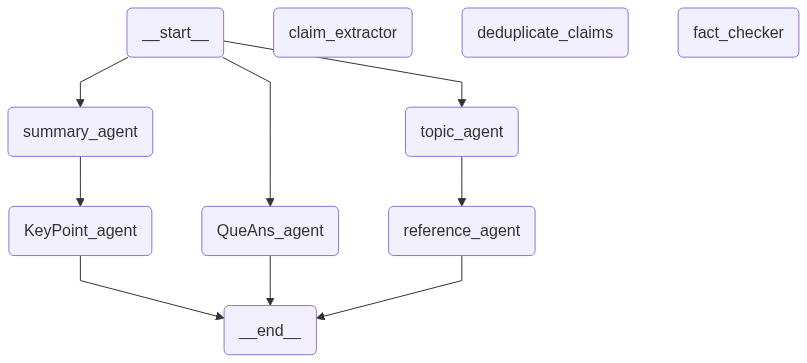

In [31]:
yt

In [33]:
result = yt.invoke({
    "video_transcript": transcript,
    "summary": "",
    "KeyPoints": [],
    "claims": [],
    "fact_check": [],
    "topics": [],
    "references": [],
    "question": "Bias vs variance",
    "context": "",
    "answer": ""
})

Ignoring unknown node name claim_chunk_agent in pending sends
Ignoring unknown node name claim_chunk_agent in pending sends


In [34]:
result

{'video_transcript': "Hurricane Florence came by while I was working on StatQuest. Dark clouds filled the sky, but that didn't stop StatQuest. StatQuest. Hello, I'm Josh Starmer and welcome to StatQuest. Today, we're going to be talking about some machine learning fundamentals, bias and variance, and they're going to be clearly explained. Imagine we measured the weight and height of a bunch of mice and plotted the data on a graph. Light mice tend to be short, and heavier mice tend to be taller. But after a certain weight, mice don't get any taller, just more obese. Given this data, we would like to predict mouse height given its weight. For example, if you told me your mouse weighed this much, then we might predict that the mouse is this tall. Ideally, we would know the exact mathematical formula that describes the relationship between weight and height. But in this case, we don't know the formula, so we're going to use two machine learning methods to approximate this relationship. How